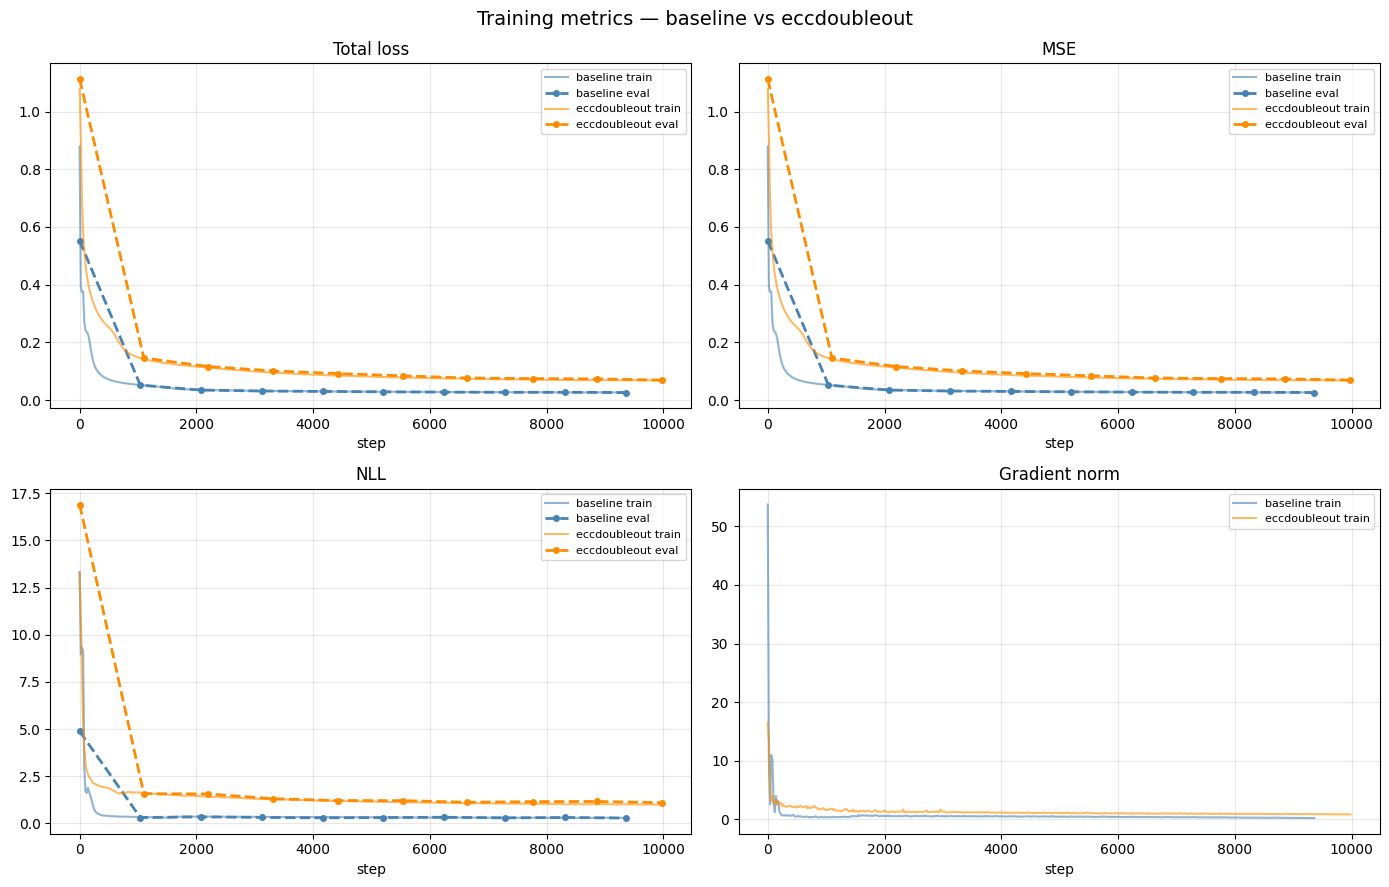

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

MODELS = {
    "baseline":     "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260504-19:40:15",
    "eccdoubleout": "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260503-19:48:44",
}

def load_model(model_dir):
    df = pd.read_csv(f"{model_dir}/progress.csv")
    train = df[df["loss"].notna()].copy()
    eval_ = df[df["eval_loss"].notna()].copy()
    eval_steps = train["step"].iloc[np.linspace(0, len(train)-1, len(eval_), dtype=int)].values
    eval_["step"] = eval_steps
    return train, eval_

data = {label: load_model(path) for label, path in MODELS.items()}

colors = {"baseline": "steelblue", "eccdoubleout": "darkorange"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Training metrics — baseline vs eccdoubleout", fontsize=14)

plots = [
    (axes[0, 0], "loss",      "eval_loss", "Total loss"),
    (axes[0, 1], "mse",       "eval_mse",  "MSE"),
    (axes[1, 0], "nll",       "eval_nll",  "NLL"),
    (axes[1, 1], "grad_norm", None,        "Gradient norm"),
]

for ax, train_col, eval_col, title in plots:
    for label, (train, eval_) in data.items():
        c = colors[label]
        ax.plot(train["step"], train[train_col], label=f"{label} train", color=c, alpha=0.6)
        if eval_col:
            ax.plot(eval_["step"], eval_[eval_col], label=f"{label} eval",
                    color=c, linestyle="--", marker="o", markersize=4, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_comparison.png", dpi=150)
plt.show()


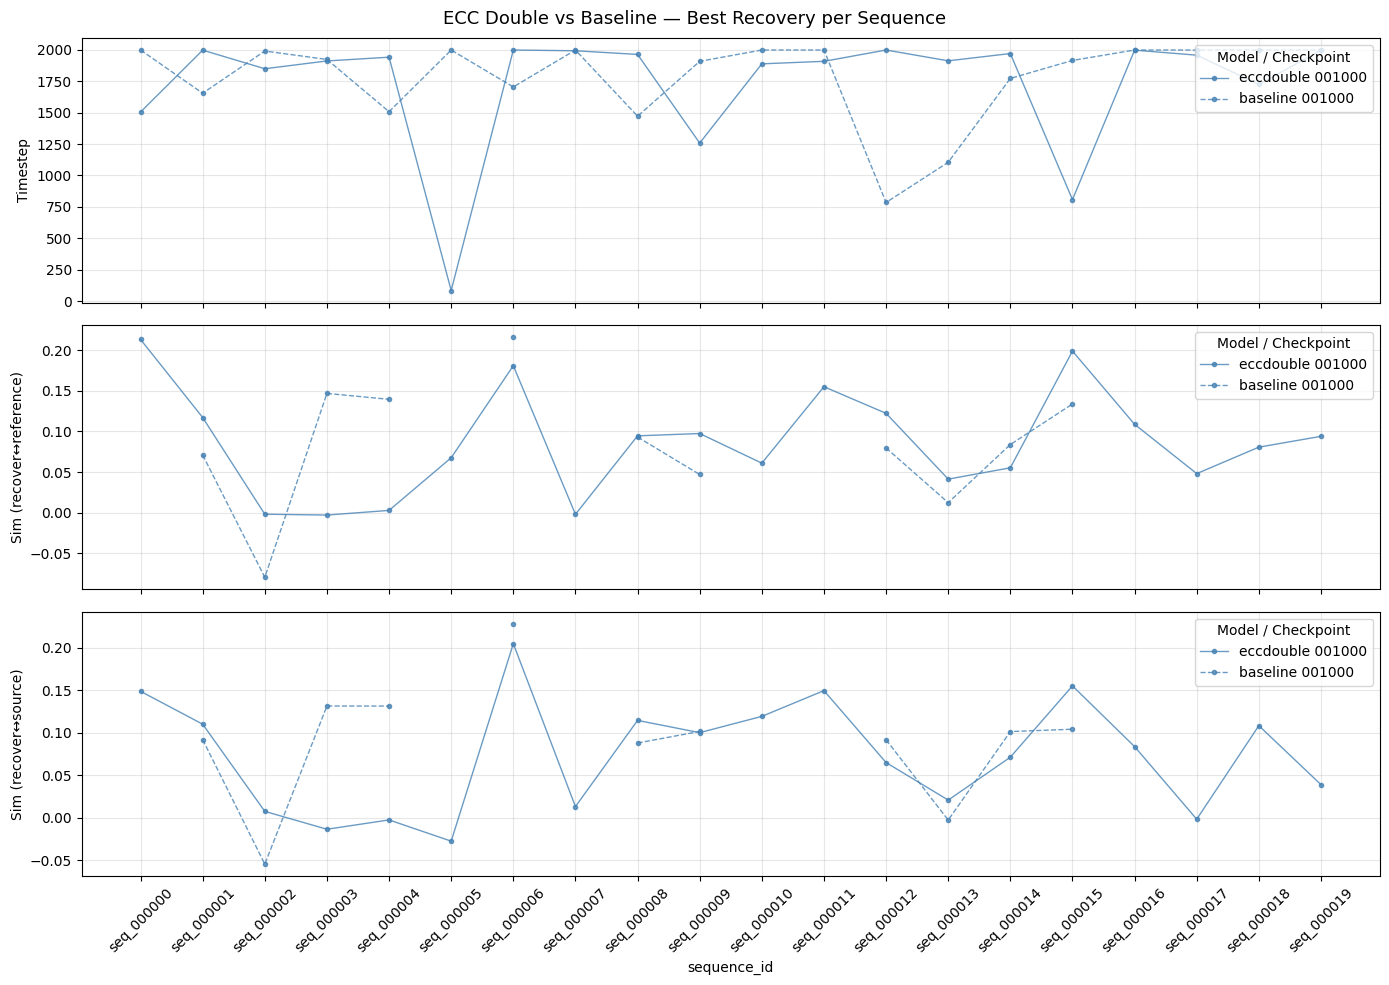

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "eccdouble 001000": "scored_recovery_steps_eccdouble_001000.parquet",
    #"eccdouble 005000": "scored_recovery_steps_eccdouble_005000.parquet",
    "baseline 001000":  "scored_recovery_steps_baseline_001000.parquet",
    #"baseline 005000":  "scored_recovery_steps_baseline_005000.parquet",
}

dfs = {}
for label, path in files.items():
    df = pd.read_parquet(path)
    best = (
        df.sort_values("sim_recover_reference", ascending=False)
        .groupby("sequence_id", as_index=False)
        .first()
        .sort_values("sequence_id")
    )
    dfs[label] = best

colors = {
    "eccdouble 001000": "steelblue",
    #"eccdouble 005000": "darkorange",
    "baseline 001000":  "steelblue",
    #"baseline 005000":  "darkorange",
}
linestyles = {
    "eccdouble 001000": "-",
    #"eccdouble 005000": "-",
    "baseline 001000":  "--",
    #"baseline 005000":  "--",
}

metrics = ["timestep", "sim_recover_reference", "sim_recover_source"]
ylabels = ["Timestep", "Sim (recover↔reference)", "Sim (recover↔source)"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    for label, best in dfs.items():
        ax.plot(
            best["sequence_id"],
            best[metric],
            label=label,
            color=colors[label],
            linestyle=linestyles[label],
            marker="o",
            markersize=3,
            linewidth=1,
            alpha=0.8,
        )
    ax.set_ylabel(ylabel)
    ax.legend(title="Model / Checkpoint", loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("sequence_id")
axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("ECC Double vs Baseline — Best Recovery per Sequence", fontsize=13)
plt.tight_layout()
plt.savefig("recovery_comparison.png", dpi=150)
plt.show()


KeyError: ['decoder_nll']

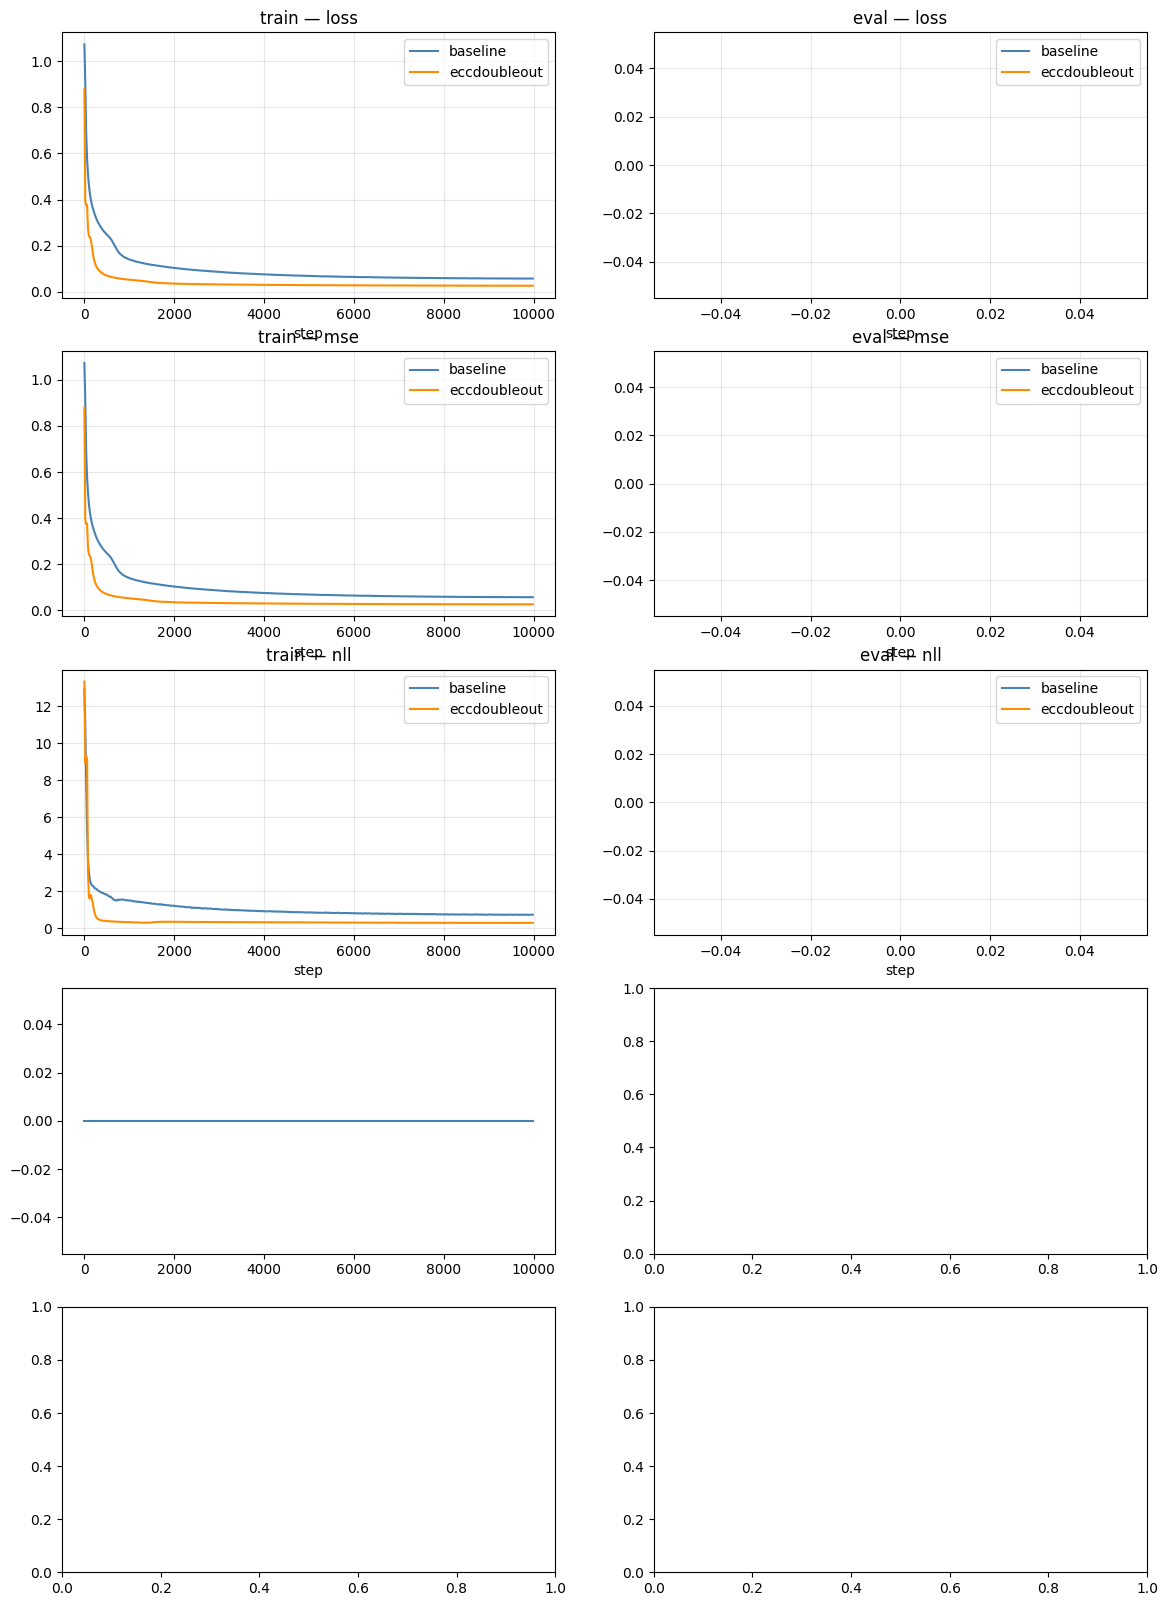

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

paths = {
    "baseline":    "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260515-15:53:34/progress.csv",
    "eccdoubleout": "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260517-11:14:29/progress.csv",
}

dfs = {}
for name, path in paths.items():
    df = pd.read_csv(path)
    df = df.dropna(subset=['step'])
    dfs[name] = df

metrics = ['loss', 'mse', 'nll', 'decoder_nll', 'tT_loss']
colors  = {'baseline': 'steelblue', 'eccdoubleout': 'darkorange'}

fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4 * len(metrics)))

for row, metric in enumerate(metrics):
    for col, split in enumerate(['train', 'eval']):
        ax = axes[row, col]
        col_name = metric if split == 'train' else f'eval_{metric}'
        for name, df in dfs.items():
            subset = df.dropna(subset=[col_name])
            ax.plot(subset['step'], subset[col_name], label=name, color=colors[name])
        ax.set_title(f'{split} — {metric}')
        ax.set_xlabel('step')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150)
plt.show()


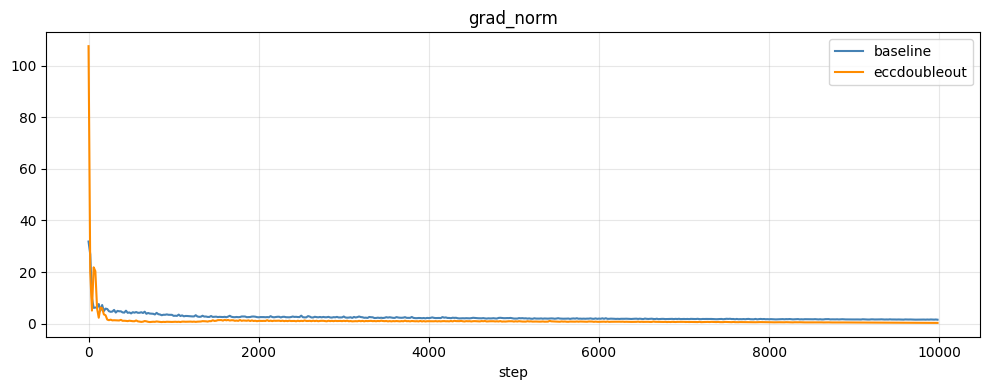

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, df in dfs.items():
    subset = df.dropna(subset=['grad_norm'])
    ax.plot(subset['step'], subset['grad_norm'], label=name, color=colors[name])
ax.set_title('grad_norm')
ax.set_xlabel('step')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grad_norm_comparison.png', dpi=150)
plt.show()


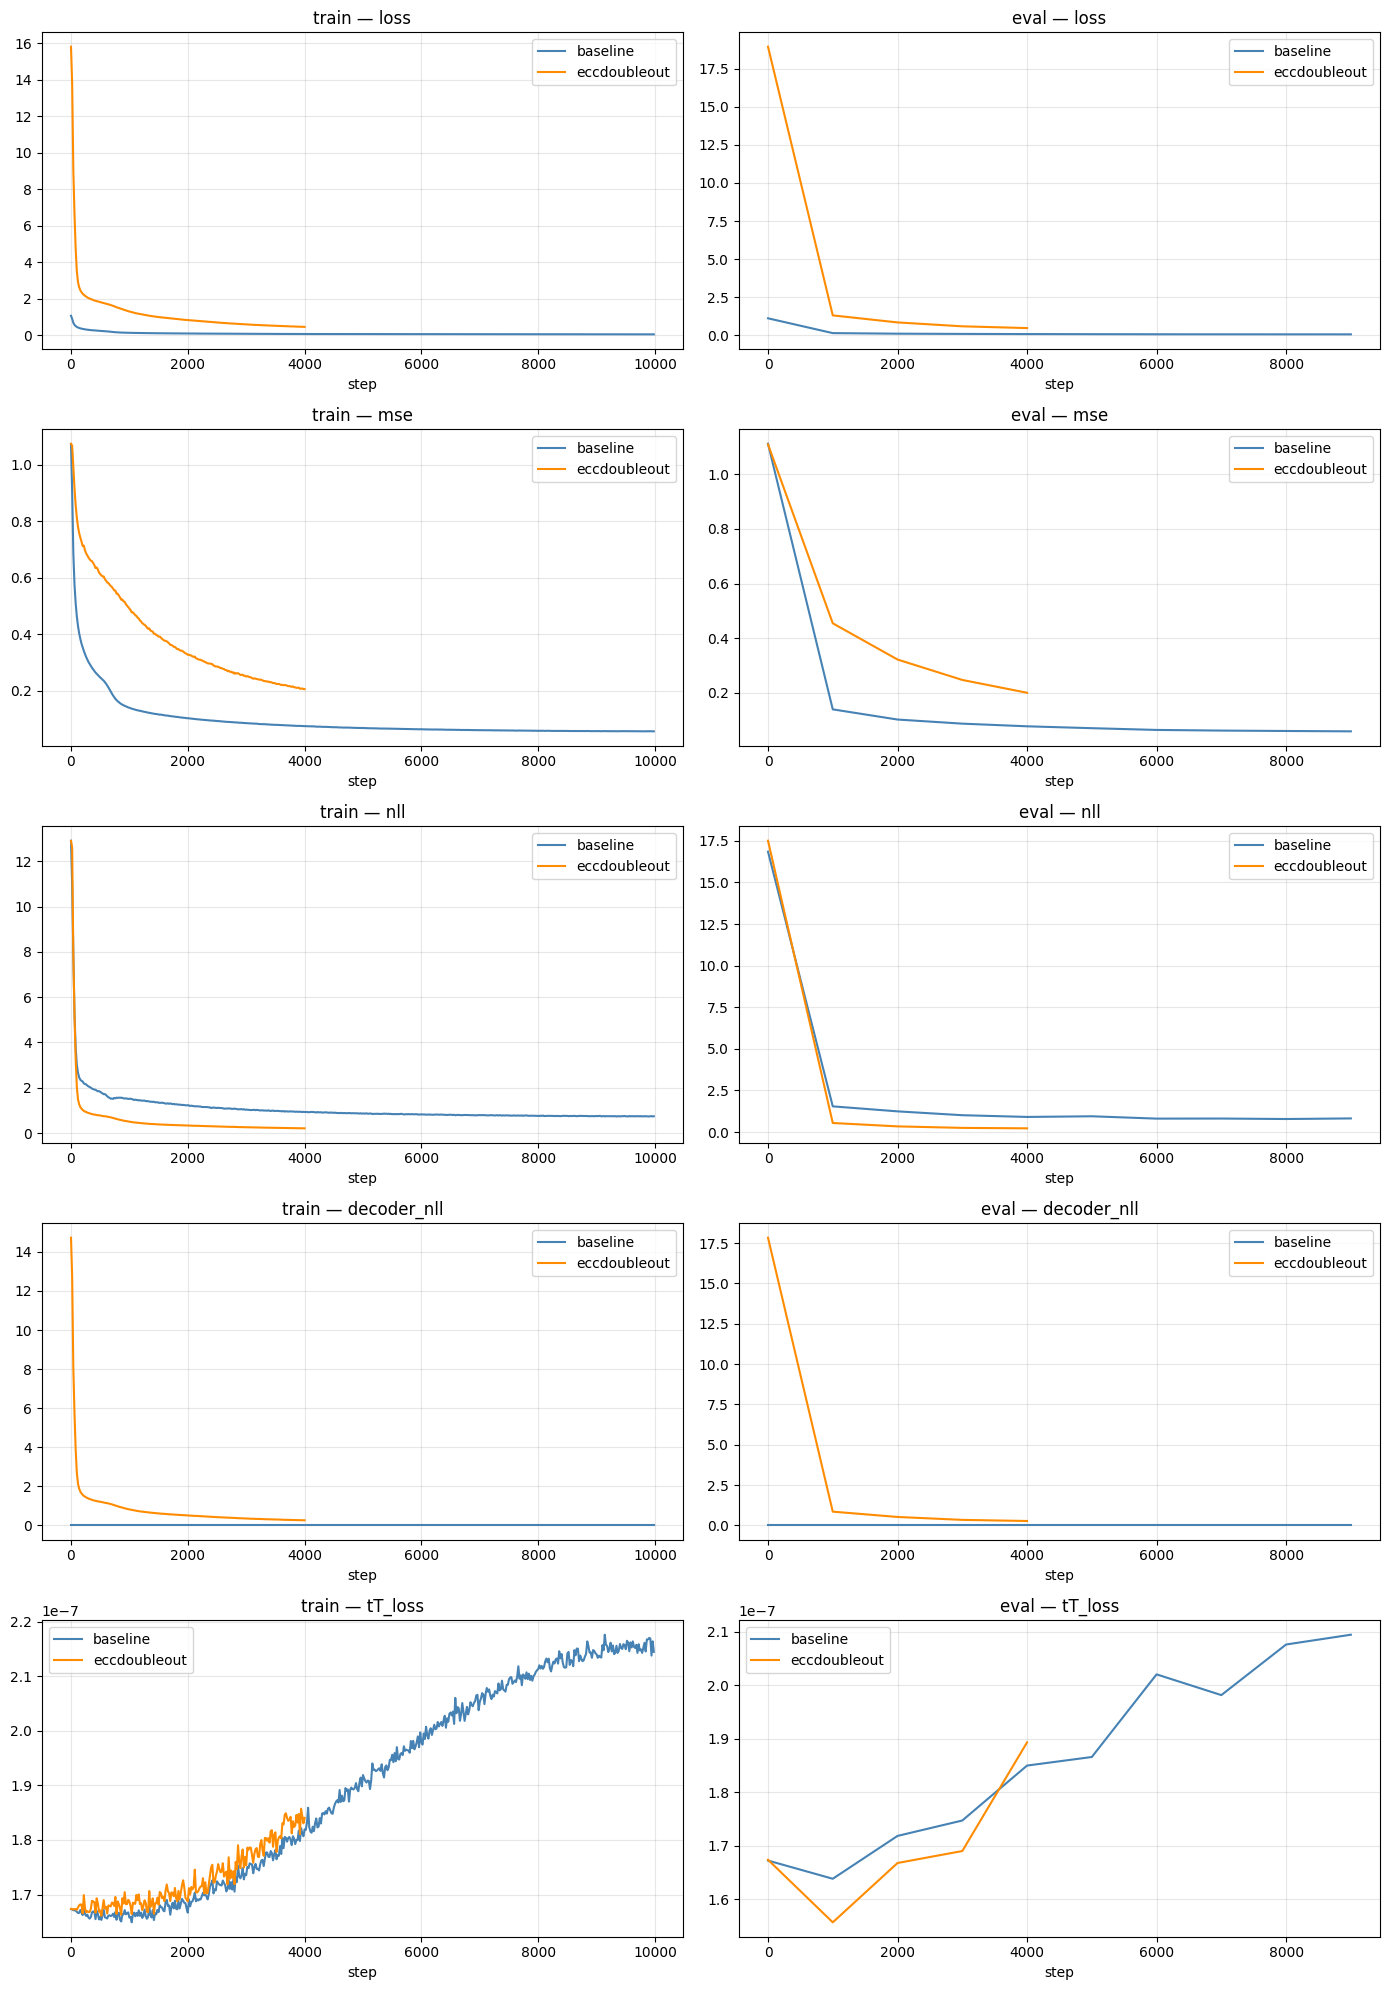

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

paths = {
    "baseline":    "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260515-15:53:34/progress.csv",
    "eccdoubleout": "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260518-21:06:11/progress.csv",
}

dfs = {}
for name, path in paths.items():
    df = pd.read_csv(path)
    df['step'] = df['step'].ffill()
    dfs[name] = df


metrics = ['loss', 'mse', 'nll', 'decoder_nll', 'tT_loss']
colors  = {'baseline': 'steelblue', 'eccdoubleout': 'darkorange'}

fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4 * len(metrics)))

for row, metric in enumerate(metrics):
    for col, split in enumerate(['train', 'eval']):
        ax = axes[row, col]
        col_name = metric if split == 'train' else f'eval_{metric}'
        for name, df in dfs.items():
            subset = df.dropna(subset=[col_name])
            ax.plot(subset['step'], subset[col_name], label=name, color=colors[name])
        ax.set_title(f'{split} — {metric}')
        ax.set_xlabel('step')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150)
plt.show()
